In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [17]:
df = pd.read_csv("travel_insurance_age_claim_200_rows.csv")
df

,Age,Claim
0,58,Yes
1,65,Yes
2,32,Yes
3,24,No
4,75,Yes
...,...,...
195,53,No
196,53,Yes
197,22,No
198,62,No


In [3]:
print("First 5 Rows")
print(df.head())

First 5 Rows
   Age Claim
0   58   Yes
1   65   Yes
2   32   Yes
3   24    No
4   75   Yes


In [4]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Age      0
Claim    0
dtype: int64


In [5]:
df.drop_duplicates(inplace=True)

print("\nDataset Shape:", df.shape)



Dataset Shape: (86, 2)


In [6]:
le = LabelEncoder()

df["Claim"] = le.fit_transform(df["Claim"])

In [7]:
X = df[["Age"]]
y = df["Claim"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [10]:
model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score")
print(round(accuracy * 100, 2), "%")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))




Accuracy Score
77.78 %

Confusion Matrix
[[7 2]
 [2 7]]

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.78      0.78         9
           1       0.78      0.78      0.78         9

    accuracy                           0.78        18
   macro avg       0.78      0.78      0.78        18
weighted avg       0.78      0.78      0.78        18



In [12]:
age = int(input("\nEnter Age: "))

user = pd.DataFrame([[age]], columns=["Age"])

user_scaled = scaler.transform(user)

prediction = model.predict(user_scaled)

probability = model.predict_proba(user_scaled)

print("\nProbability")

print("Not Claim :", round(probability[0][0] * 100, 2), "%")
print("Claim     :", round(probability[0][1] * 100, 2), "%")

if prediction[0] == 1:
    print("\nRESULT : CLAIM")
else:
    print("\nRESULT : NOT CLAIM")




Enter Age: 23

Probability
Not Claim : 60.9 %
Claim     : 39.1 %

RESULT : NOT CLAIM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


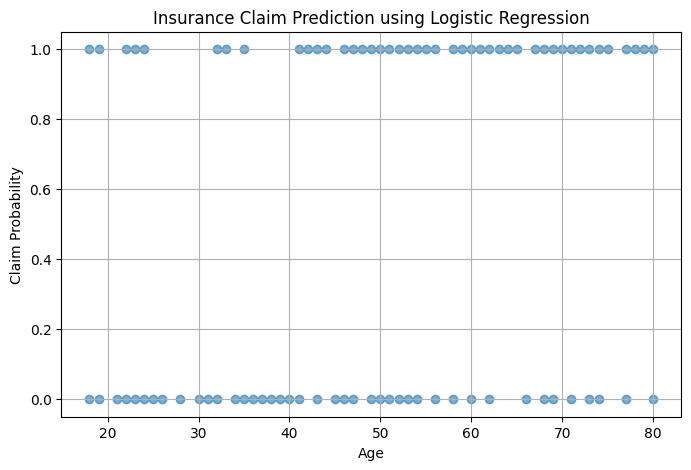

In [14]:
x_range = np.linspace(
    df["Age"].min(),
    df["Age"].max(),
    300
).reshape(-1, 1)

x_range_scaled = scaler.transform(x_range)

y_prob = model.predict_proba(x_range_scaled)[:, 1]

plt.figure(figsize=(8,5))

plt.scatter(
    df["Age"],
    df["Claim"],
    alpha=0.6
)


plt.xlabel("Age")
plt.ylabel("Claim Probability")
plt.title("Insurance Claim Prediction using Logistic Regression")
plt.grid(True)

plt.show()